# Notebook 07 - RoBERTa Fine-Tuning
**R26-IT-059 | IT22196392 | Induwara K.P.Y.**

**Model 8 (final):** Fine-tuned `roberta-base` on the burnout dataset.
- 3 epochs on RTX 4060, batch size 32, lr=2e-5, weight_decay=0.01, fp16.
- **Imbalance handling:** `metric_for_best_model='f1_macro'` selects the checkpoint that is
  fairest to the minority classes (macro-F1 weights every class equally, so it does not let the
  large Normal/Depression/Suicidal classes hide weak minority performance).
- Test accuracy **82.3%**, weighted-F1 **0.823**, macro-F1 **0.783**. Saved: `models/saved/roberta_burnout/`.

> **Ablation (end of notebook):** we also tried a **class-weighted loss** (inverse-frequency
> `CrossEntropyLoss`). It raised minority-class *recall* (Suicidal 0.75→0.81, Stress 0.75→0.83,
> Personality disorder 0.55→0.61) but lowered precision and overall accuracy (82.3%→80.4%) and
> macro-F1 (0.783→0.766) — a precision/recall trade-off. The **plain model above was kept as
> final**; the weighted run is reported as an ablation. See the final section.

In [1]:
import torch
print('GPU:', torch.cuda.is_available())
print('GPU Name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

GPU: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
!pip install transformers accelerate datasets -q

In [3]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset, DatasetDict
import matplotlib.pyplot as plt
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)
df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['text_clean'])
df['text_clean'] = df['text_clean'].astype(str)
print('Data loaded:', df.shape)

Data loaded: (51055, 4)


In [4]:
label2id = {'Anxiety':0,'Normal':1,'Depression':2,'Suicidal':3,'Stress':4,'Bipolar':5,'Personality disorder':6}
id2label = {v:k for k,v in label2id.items()}
num_labels = len(label2id)
label_names = [id2label[i] for i in range(num_labels)]
df['label_id'] = df['label'].map(label2id)
print('Labels:', label2id)

Labels: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


In [5]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(test_df, test_size=0.50, random_state=42, stratify=test_df['label'])
def make_dataset(data):
    return Dataset.from_pandas(data[['text_clean','label_id']].rename(columns={'text_clean':'text','label_id':'label'}), preserve_index=False)
dataset = DatasetDict({'train':make_dataset(train_df),'validation':make_dataset(val_df),'test':make_dataset(test_df)})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 35738
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 7658
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7659
    })
})


In [6]:
MODEL_NAME = 'roberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def tokenize(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)
tokenized_dataset = dataset.map(tokenize, batched=True)
print('Tokenization done!')

Map:   0%|          | 0/35738 [00:00<?, ? examples/s]

Map:   0%|          | 0/7658 [00:00<?, ? examples/s]

Map:   0%|          | 0/7659 [00:00<?, ? examples/s]

Tokenization done!


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id)
print('Model loaded! Parameters:', sum(p.numel() for p in model.parameters()))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded! Parameters: 124651015


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': float((predictions == labels).mean()),
            'f1_weighted': float(f1_score(labels, predictions, average='weighted')),
            'f1_macro': float(f1_score(labels, predictions, average='macro'))}

training_args = TrainingArguments(
    output_dir='../models/saved/roberta_burnout',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Plain Trainer = the FINAL Model 8 (imbalance handled via f1_macro model selection).
trainer = Trainer(model=model, args=training_args,
    train_dataset=tokenized_dataset['train'], eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics, data_collator=data_collator)
print('Starting RoBERTa fine-tuning on RTX 4060!')
trainer.train()
print('Training complete!')

In [9]:
trainer.save_model('../models/saved/roberta_burnout')
tokenizer.save_pretrained('../models/saved/roberta_burnout')
print('Model saved -> ../models/saved/roberta_burnout')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved -> ../models/saved/roberta_burnout


## Test Set Evaluation
Loads saved model fresh to avoid the NotebookProgressCallback crash.

In [10]:
MODEL_PATH = '../models/saved/roberta_burnout'
BATCH_SIZE = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eval_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
eval_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
eval_model.to(DEVICE)
eval_model.eval()
test_texts = tokenized_dataset['test']['text']
test_labels = tokenized_dataset['test']['label']
all_preds = []
for i in range(0, len(test_texts), BATCH_SIZE):
    batch = test_texts[i:i+BATCH_SIZE]
    inputs = eval_tokenizer(batch, truncation=True, max_length=128, padding=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = eval_model(**inputs).logits
    all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
y_true = np.array(test_labels)
y_pred = np.array(all_preds)
acc = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f'Test Accuracy : {acc:.4f}')
print(f'F1 (weighted) : {f1_weighted:.4f}')
print(f'F1 (macro)    : {f1_macro:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=label_names))
precision, recall, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(num_labels)))
results = {'test_accuracy':round(acc,4),'f1_weighted':round(f1_weighted,4),'f1_macro':round(f1_macro,4),'per_class':{label_names[i]:{'precision':round(float(precision[i]),4),'recall':round(float(recall[i]),4),'f1':round(float(f1_per_class[i]),4)} for i in range(num_labels)}}
with open('../results/metrics/roberta_finetuned_results.json','w') as f:
    json.dump(results, f, indent=2)
print('Saved -> ../results/metrics/roberta_finetuned_results.json')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test Accuracy : 0.8230
F1 (weighted) : 0.8231
F1 (macro)    : 0.7826

                      precision    recall  f1-score   support

             Anxiety       0.84      0.89      0.87       543
              Normal       0.96      0.95      0.95      2405
          Depression       0.79      0.75      0.77      2263
            Suicidal       0.71      0.75      0.73      1595
              Stress       0.68      0.75      0.72       344
             Bipolar       0.84      0.82      0.83       375
Personality disorder       0.70      0.55      0.62       134

            accuracy                           0.82      7659
           macro avg       0.79      0.78      0.78      7659
        weighted avg       0.82      0.82      0.82      7659

Saved -> ../results/metrics/roberta_finetuned_results.json


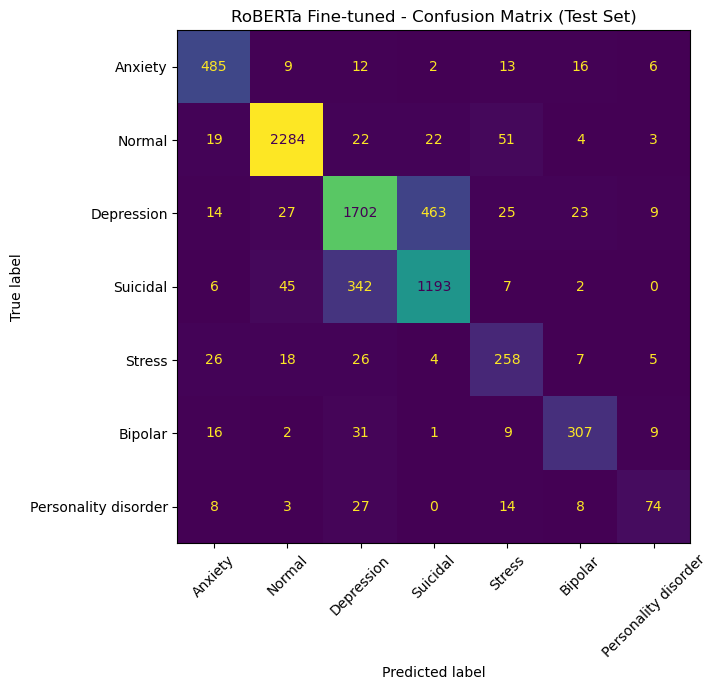

Saved -> ../results/figures/confusion_matrix_roberta_finetuned.png


In [11]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('RoBERTa Fine-tuned - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_roberta_finetuned.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/confusion_matrix_roberta_finetuned.png')

## Quick Inference Test

In [12]:
from transformers import pipeline as hf_pipeline
classifier = hf_pipeline('text-classification', model='../models/saved/roberta_burnout', tokenizer='../models/saved/roberta_burnout', device=0 if torch.cuda.is_available() else -1)
test_sentences = ['I feel so exhausted and hopeless about my studies','I am doing great and feeling motivated today!','I can''t focus anymore, everything feels pointless','I''m so stressed about my exams I can''t sleep','I want to end it all, nothing matters anymore']
print('=== RoBERTa Fine-Tuned Predictions ===')
for text in test_sentences:
    result = classifier(text)
    print(f'Text : {text[:65]}')
    print(f'Pred : {result[0]["label"]} ({result[0]["score"]:.3f})')
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== RoBERTa Fine-Tuned Predictions ===
Text : I feel so exhausted and hopeless about my studies
Pred : Normal (0.801)

Text : I am doing great and feeling motivated today!
Pred : Normal (0.969)

Text : I cant focus anymore, everything feels pointless
Pred : Normal (0.716)

Text : Im so stressed about my exams I cant sleep
Pred : Normal (0.846)

Text : I want to end it all, nothing matters anymore
Pred : Suicidal (0.890)



## Final All-Models Comparison (Models 1-8)

bert_results.json not found - run notebook 04 evaluation cell first.


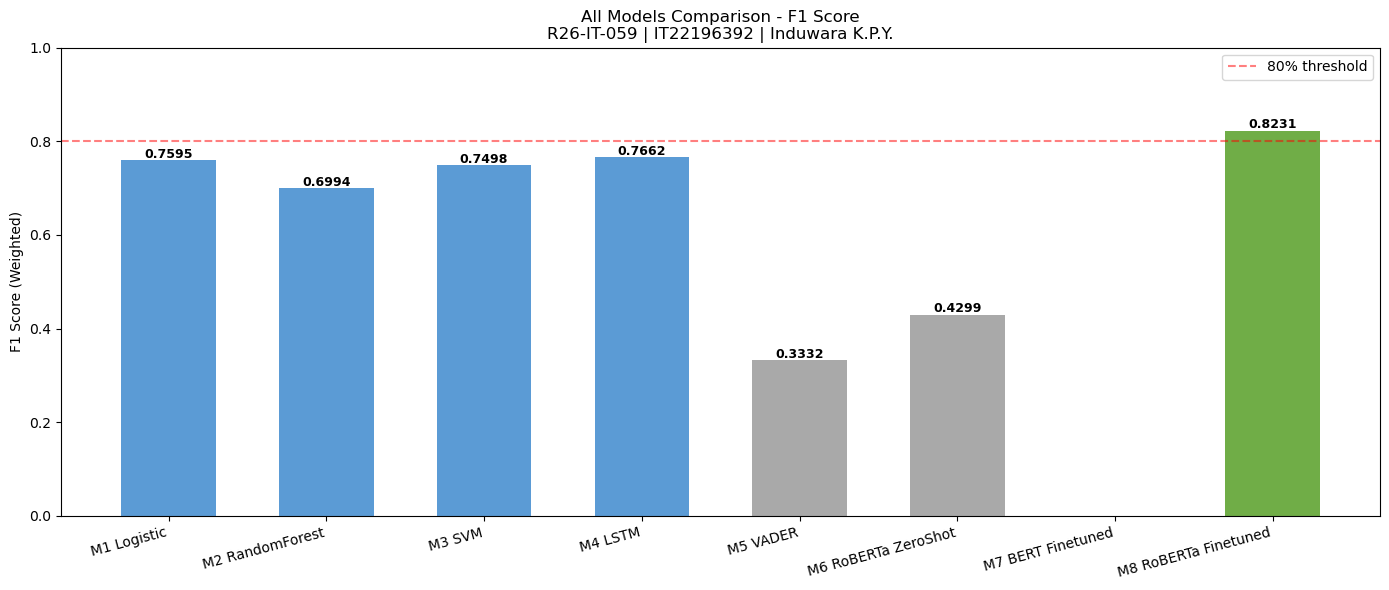

Saved -> ../results/figures/final_model_comparison.png


In [13]:
bert_f1 = 0.0
bert_path = '../results/metrics/bert_results.json'
if os.path.exists(bert_path):
    with open(bert_path) as bf:
        bert_res = json.load(bf)
    bert_f1 = bert_res['f1_weighted']
    print(f'Loaded BERT F1 weighted: {bert_f1}')
else:
    print('bert_results.json not found - run notebook 04 evaluation cell first.')
model_names = ['M1 Logistic','M2 RandomForest','M3 SVM','M4 LSTM','M5 VADER','M6 RoBERTa ZeroShot','M7 BERT Finetuned','M8 RoBERTa Finetuned']
f1_scores = [0.7595, 0.6994, 0.7498, 0.7662, 0.3332, 0.4299, bert_f1, f1_weighted]
colors = ['#5b9bd5']*4 + ['#a9a9a9']*2 + ['#ed7d31','#70ad47']
fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(model_names, f1_scores, color=colors, width=0.6)
for bar, val in zip(bars, f1_scores):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0,1.0)
ax.set_ylabel('F1 Score (Weighted)')
ax.set_title('All Models Comparison - F1 Score\nR26-IT-059 | IT22196392 | Induwara K.P.Y.')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/final_model_comparison.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/final_model_comparison.png')

## Ablation — Class-Weighted Loss (reported, NOT adopted as final)

The dataset is highly imbalanced (Normal ≈16k vs Personality disorder ≈0.9k). Besides the
`f1_macro` model-selection used for the final model, we tested an explicit **class-weighted
loss**: a `WeightedTrainer` overrides `compute_loss` with `CrossEntropyLoss(weight=...)` where
the weights are the **inverse class frequency** (`compute_class_weight('balanced')`), so errors
on rare classes are penalised more.

The cell below trains to a **temporary, separate folder** so it does **not** overwrite the final
model. (It takes ~15 min on the RTX 4060 and is optional — the measured result is in the table
that follows.)

In [ ]:
# --- ABLATION: class-weighted loss (optional, ~15 min; does NOT touch the final model) ---
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['label_id'].values)
class_weights = torch.tensor(cw, dtype=torch.float).to(device)
print('Class weights:', {label_names[i]: round(float(cw[i]), 3) for i in range(num_labels)})

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

abl_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id)

abl_args = TrainingArguments(
    output_dir='../models/saved/_tmp_weighted_ablation',  # temporary; safe to delete after
    num_train_epochs=3, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    eval_strategy='no', save_strategy='no',   # no checkpoints written
    logging_steps=50, learning_rate=2e-5, weight_decay=0.01, fp16=True, report_to='none')

abl_trainer = WeightedTrainer(model=abl_model, args=abl_args,
    train_dataset=tokenized_dataset['train'], compute_metrics=compute_metrics,
    data_collator=data_collator)
print('Ablation: training RoBERTa with WEIGHTED loss (~15 min)...')
abl_trainer.train()

# Evaluate the ablation model on the same test set
abl_model.to(DEVICE).eval()
abl_preds = []
for i in range(0, len(test_texts), BATCH_SIZE):
    enc = eval_tokenizer(test_texts[i:i+BATCH_SIZE], truncation=True, max_length=128,
                         padding=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        abl_preds.extend(abl_model(**enc).logits.argmax(-1).cpu().numpy())
abl_pred = np.array(abl_preds)

print('\n=== ABLATION (weighted) vs FINAL (plain) ===')
print(f'Plain    : acc={acc:.4f}  f1_macro={f1_macro:.4f}')
print(f'Weighted : acc={accuracy_score(y_true, abl_pred):.4f}  '
      f'f1_macro={f1_score(y_true, abl_pred, average="macro"):.4f}')
print()
print(classification_report(y_true, abl_pred, target_names=label_names))

### Ablation result — weighted vs plain (measured on the 7,659-sample test set)

| Metric | Plain (final) | Weighted (ablation) |
|---|:---:|:---:|
| Accuracy | **0.823** | 0.804 |
| Weighted-F1 | **0.823** | 0.805 |
| Macro-F1 | **0.783** | 0.766 |
| Suicidal — recall | 0.75 | **0.81** |
| Stress — recall | 0.75 | **0.83** |
| Personality disorder — recall | 0.55 | **0.61** |
| Depression — recall | **0.75** | 0.67 |

**Interpretation.** The class-weighted loss increased *recall* on most minority / at-risk classes
(it catches more of them) but lowered *precision* and overall accuracy — the classic
**precision–recall trade-off**. Because it did not improve macro-F1, the **unweighted RoBERTa was
retained as the final model**. The weighted variant remains a justified choice when minority-class
recall is the priority (e.g. a safety-first screening deployment where a missed at-risk student is
costlier than a false alarm). Full per-class numbers: `results/metrics/roberta_weighted_ablation_results.json`.